In [1]:
# ipca_pipeline.py (or paste into a notebook cell)

from __future__ import annotations
import os
import contextlib
from dataclasses import dataclass
from typing import List, Tuple, Optional, Dict, Any

import numpy as np
import pandas as pd
from ipca import InstrumentedPCA

def run_pipeline(
    start_yyyymm: str = "199001",
    end_yyyymm: str = "202412",
    max_nan_frac: float = 0.6,
    cutoff: str = "2015-12-31",
    n_factors: int = 3,
) -> Dict[str, Any]:
    df_raw = download_openap_data(start_yyyymm, end_yyyymm)
    df_keep, dropped = remove_mostly_nan_columns(df_raw, max_nan_frac=max_nan_frac)
    df_filled = fill_remaining_missing(df_keep)

    panel = build_ipca_panel(df_filled, ret_col="excess_ret", shift_target=True)
    train_df, test_df = split_train_test_by_date(panel.df, cutoff=cutoff)

    X_train = train_df[panel.char_cols].to_numpy(np.float64)
    y_train = train_df["y_ipca"].to_numpy(np.float64)
    idx_train = train_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    X_test = test_df[panel.char_cols].to_numpy(np.float64)
    y_test = test_df["y_ipca"].to_numpy(np.float64)
    idx_test = test_df[["i_idx", "t_idx"]].to_numpy(np.int64)

    mod = fit_ipca(X_train, y_train, idx_train, n_factors=n_factors, silent=True)
    r2_train = score_ipca(mod, X_train, y_train, idx_train, mean_factor=False)
    r2_test = score_ipca(mod, X_test, y_test, idx_test, mean_factor=True)  # unseen dates

    return {
        "model": mod,
        "dropped_cols": dropped,
        "char_cols": panel.char_cols,
        "r2_train": r2_train,
        "r2_test_mean_factor": r2_test,
        "train_shape": X_train.shape,
        "test_shape": X_test.shape,
    }


In [2]:
%cd /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master
import sys, importlib
import importlib
import src.ipca_workflow as IPCAWorkflow
importlib.reload(IPCAWorkflow)

/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master


<module 'src.ipca_workflow' from '/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/src/ipca_workflow.py'>

In [4]:
out_path = "/Users/apple/Desktop/Academics/char_data.parquet"
char_data = pd.read_parquet(out_path, engine="pyarrow")

In [5]:
from src.data_pipeline import DataPipeline

new_mod = DataPipeline()  # or keep your existing instance if already created

char_data, dropped_cols = new_mod.remove_mostly_nan_columns(char_data, max_nan_frac=0.5)
print(f"Dropped columns: {dropped_cols}")

returns_data = new_mod.download_sp500_returns_wrds(
    start_date="1990-01-01",
    end_date="2026-01-31",
)

Dropped columns: ['AOP', 'AbnormalAccruals', 'AccrualsBM', 'Activism1', 'Activism2', 'AdExp', 'AgeIPO', 'AnalystRevision', 'AnalystValue', 'BetaTailRisk', 'BrandInvest', 'CBOperProf', 'CPVolSpread', 'Cash', 'ChAssetTurnover', 'ChForecastAccrual', 'ChInvIA', 'ChNAnalyst', 'ChangeInRecommendation', 'CitationsRD', 'CompEquIss', 'CompositeDebtIssuance', 'ConsRecomm', 'CustomerMomentum', 'DelBreadth', 'DelDRC', 'DivSeason', 'DivYieldST', 'DownRecomm', 'EP', 'EarnSupBig', 'EarningsConsistency', 'EarningsForecastDisparity', 'EarningsStreak', 'EarningsSurprise', 'EntMult', 'ExclExp', 'FEPS', 'FR', 'FirmAgeMom', 'ForecastDispersion', 'Frontier', 'Governance', 'GrAdExp', 'GrSaleToGrInv', 'GrSaleToGrOverhead', 'HerfAsset', 'HerfBE', 'IO_ShortInterest', 'IndRetBig', 'IntanBM', 'IntanCFP', 'IntanEP', 'IntanSP', 'InvGrowth', 'Investment', 'MS', 'MeanRankRevGrowth', 'Mom6mJunk', 'MomOffSeason06YrPlus', 'MomOffSeason11YrPlus', 'MomOffSeason16YrPlus', 'MomRev', 'MomSeason06YrPlus', 'MomSeason11YrPlus',

In [6]:
char_data, kept_chars, dropped_chars = new_mod.drop_low_std_and_high_corr(
    char_data,
    min_std=1e-5,   # tune as needed
    max_corr=0.75,  # tune as needed
)

/usr/local/lib/python3.11/site-packages/numpy/core/_methods.py:49: RuntimeWarning: invalid value encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.11/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


In [7]:
char_data = new_mod.fill_remaining_missing(char_data)

/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
/usr/local

In [8]:
char_data_copy = char_data.copy()
char_data.head()

,permno,yyyymm,AM,AnnouncementReturn,AssetGrowth,BMdec,Beta,BetaFP,BetaLiquidityPS,BidAskSpread,...,ShareRepurchase,Spinoff,Tax,VolSD,VolumeTrend,betaVIX,hire,Price,Size,STreversal
0,10000,1986-01-01,1.354349,-0.005048,-0.079363,0.812997,0.939402,0.950803,-0.003676,0.010201,...,0.0,0.0,0.605906,-0.132456,-0.007507,-0.005223,-0.003373,-1.475906,-2.778819,-0.000000
1,10000,1986-02-01,1.288478,-0.006319,-0.078568,0.810572,0.943105,0.946533,-0.002954,0.009883,...,0.0,0.0,0.607135,-0.135303,-0.008091,-0.003476,-0.002513,-1.178655,-2.481568,0.257143
2,10000,1986-03-01,1.241767,-0.005388,-0.077011,0.810708,0.940686,0.945886,-0.003437,0.009717,...,0.0,0.0,0.629491,-0.139121,-0.009545,-0.002722,-0.001701,-1.490091,-2.793004,-0.365385
3,10000,1986-04-01,1.235495,-0.004667,-0.076508,0.810708,0.941277,0.885681,0.001821,0.009709,...,0.0,0.0,0.628357,-0.142124,-0.010400,0.000880,-0.000655,-1.386294,-2.719452,0.098592
4,10000,1986-05-01,1.190630,-0.001813,-0.076775,0.805317,0.940010,0.875988,-0.000560,0.009856,...,0.0,0.0,0.628310,-0.140521,-0.010711,0.008871,-0.001751,-1.134423,-2.467581,0.222656


In [9]:
returns_data = returns_data.rename(columns={"excess_ret": "ret_adj"})
char_data = new_mod.merge_openap_with_crsp_returns(char_data, returns_data)

In [8]:
import sys, importlib
from pathlib import Path

ROOT = Path("/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Clear cached mixed imports
for name in list(sys.modules):
    if name == "ipca" or name.startswith("ipca."):
        del sys.modules[name]

import ipca
import ipca.ipca as ipca_mod

print("ipca package:", ipca.__file__)
print("ipca module :", ipca_mod.__file__)

from ipca import InstrumentedPCA


ipca package: /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/__init__.py
ipca module : /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/ipca.py


In [10]:
char_data["y_ipca"] = char_data["excess_ret"].shift(-1)  # next period's return as target

In [36]:
import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)
import ipca as ipca
importlib.reload(ipca)
wf = ipw.IPCAWorkflow()
k = 5
pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
    char_data=char_data,
    forecast_start="2020-01-01",
    target_col="y_ipca",
    n_factors=k,              # use k here
    train_window_months=36,
    min_train_obs=500,
    normalize=True,
    mean_factor=True,
    silent=True,
    max_iter=15,
    iter_tol=1e-3,
    warm_start=True,
    use_rff=False,
)

Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=False, warm_Factors=False
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA w

In [38]:
# Overall OOS R²
ss_res = ((pred_df_in["y_true"] - pred_df_in["y_pred"]) ** 2).sum()
ss_tot = (pred_df_in["y_true"] ** 2).sum()  # demeaned vs zero (standard in asset pricing)
r2_oos = 1 - ss_res / ss_tot
print(f"OOS R²: {r2_oos:.4f}")

OOS R²: -9.1698


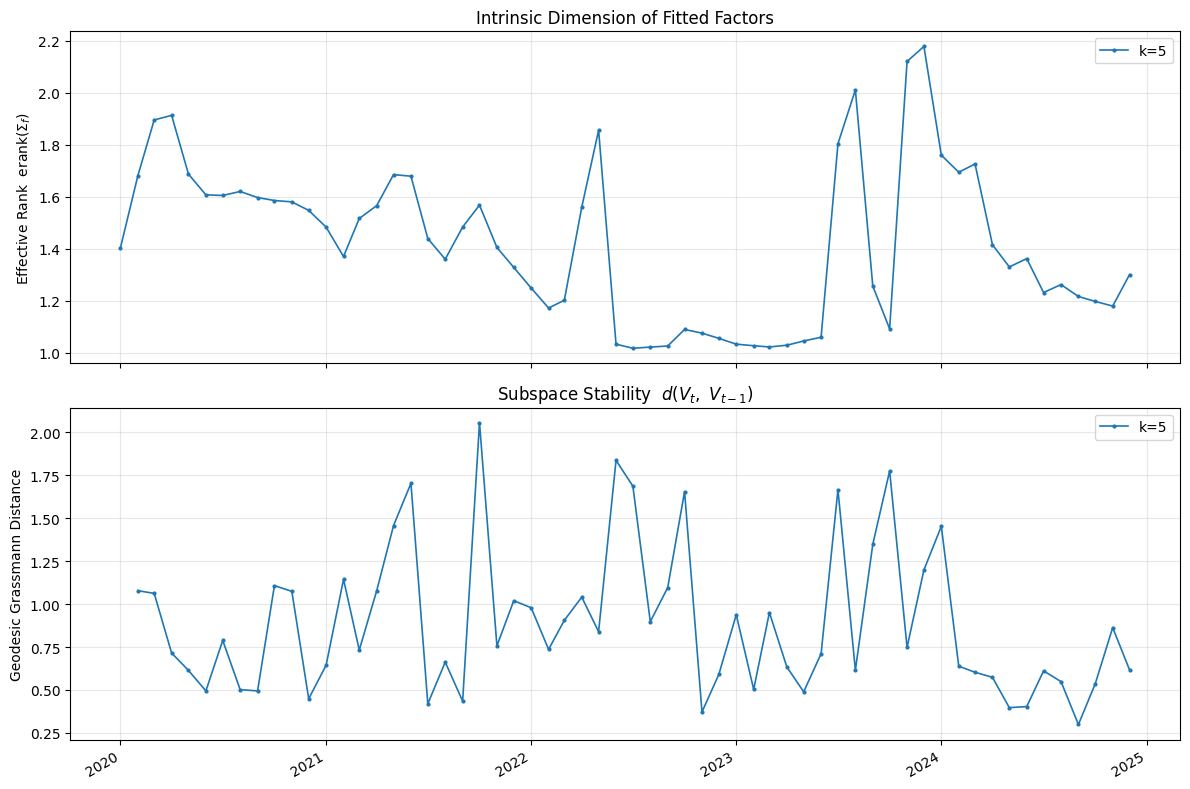

In [39]:
diag_dfs = {"k=5": diag_df_in}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for label, df in diag_dfs.items():
    t = pd.to_datetime(df["yyyymm"])
    axes[0].plot(t, df["erank"], marker="o", markersize=2, linewidth=1.2, label=label)
    axes[1].plot(t, df["grassmann_dist"], marker="o", markersize=2, linewidth=1.2, label=label)

axes[0].set_ylabel("Effective Rank  erank($\\Sigma_f$)")
axes[0].set_title("Intrinsic Dimension of Fitted Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Geodesic Grassmann Distance")
axes[1].set_title("Subspace Stability  $d(V_t,\\ V_{t-1})$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator())

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [40]:
diag_df_in.mean()

yyyymm            2022-06-16 15:12:00
erank                        1.421367
grassmann_dist               0.885374
n_train                   1551.383333
n_test                      44.816667
dtype: object

In [3]:
import sys, importlib
from pathlib import Path

ROOT = Path("/Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

# Clear cached mixed imports
for name in list(sys.modules):
    if name == "ipca" or name.startswith("ipca."):
        del sys.modules[name]

import ipca
import ipca.ipca as ipca_mod

print("ipca package:", ipca.__file__)
print("ipca module :", ipca_mod.__file__)

from ipca import InstrumentedPCA


ipca package: /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/__init__.py
ipca module : /Users/apple/Desktop/Academics/Research_work/TheVirtueOfComplexity_PaperReplication_Experimentation-master/ipca/ipca.py


In [ ]:
char_data["permno"] = pd.to_numeric(char_data["permno"], errors="coerce")
returns_data["permno"] = pd.to_numeric(returns_data["permno"], errors="coerce")

# Top 50 by median market cap (uses CRSP prc * shrout)
top50_permnos = (
    returns_data
    .assign(mcap=lambda d: d["prc"].abs() * d["shrout"])
    .dropna(subset=["permno", "mcap"])
    .groupby("permno")["mcap"]
    .median()
    .nlargest(50)
    .index
)

# Filter panel to those 50 stocks
char_data_50 = (
    char_data[char_data["permno"].isin(top50_permnos)]
    .sort_values(["yyyymm", "permno"])
    .reset_index(drop=True)
)

print("Stocks kept:", char_data_50["permno"].nunique(), "Rows:", len(char_data_50))

Stocks kept: 50 Rows: 13205


In [15]:
char_data = char_data_50.copy()

In [ ]:
import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)
import ipca as ipca
importlib.reload(ipca)
wf = ipw.IPCAWorkflow()
k = 5
pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
    char_data=char_data,
    forecast_start="2020-01-01",
    target_col="y_ipca",
    n_factors=k,              # use k here
    train_window_months=36,
    min_train_obs=500,
    normalize=True,
    mean_factor=True,
    silent=False,
    max_iter=15,
    iter_tol=1e-3,
    warm_start=True,
    use_rff=True,             # auto-switches to ridge solver
    rff_n_components=500,
    rff_gamma=0.25,
    rff_random_state=42,
)


Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=False, warm_Gamma=False, warm_Factors=False
The panel dimensions are:
n_samples: 43 , L: 1000 , T: 36


[========================================================================] 100%


Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 1 - Aggregate Update: 0.6155318604996843
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 2 - Aggregate Update: 0.03738424272283147
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 3 - Aggregate Update: 0.03824528942781114
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 4 - Aggregate Update: 0.036822471102027354
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 5 - Aggregate Update: 0.03692628898810654
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 6 - Aggregate Update: 0.0340731043841865

Step 16 - Aggregate Update: 0.03166829714266251
-- Convergence Reached --
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=False, warm_Gamma=True, warm_Factors=True
The panel dimensions are:
n_samples: 43 , L: 1000 , T: 36


[========================================================================] 100%


...

[========================================================================] 100%


Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 1 - Aggregate Update: 25736.11972013561
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 2 - Aggregate Update: 923.2217109777102
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 3 - Aggregate Update: 1169.3777630989932
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 4 - Aggregate Update: 1689.4804325056948
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 5 - Aggregate Update: 1762.7959092353015
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 6 - Aggregate Update: 1087.1148833973666
Gamma 

Step 16 - Aggregate Update: 18.680716110644425
-- Convergence Reached --
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=False, warm_Gamma=True, warm_Factors=True
The panel dimensions are:
n_samples: 49 , L: 1000 , T: 36


[========================================================================] 100%


Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 1 - Aggregate Update: 13762.050433491695
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 2 - Aggregate Update: 503.00543777672465
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 3 - Aggregate Update: 665.2266605152518
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 4 - Aggregate Update: 864.8294698602167
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 5 - Aggregate Update: 991.3109097095157
Gamma fit solver: Ridge, alpha=0.001, l1_ratio=0, ridge_solver=svd
Ridge regression with alpha = 0.001 and solver = svd
Step 6 - Aggregate Update: 856.7220665546047
Gamma fi

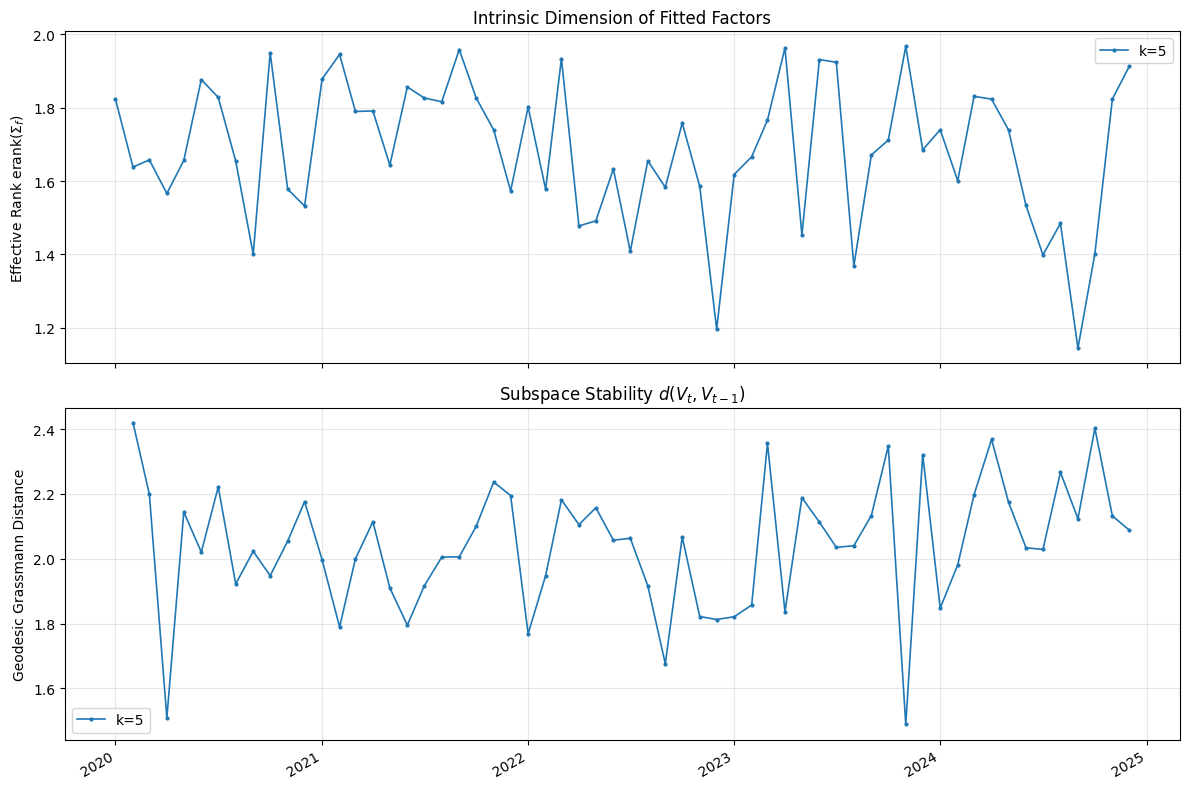

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

diag_dfs = {"k=5": diag_df_in}

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for label, df in diag_dfs.items():
    d = df.copy()

    # robust date parsing + sort
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d = d.dropna(subset=["yyyymm"]).sort_values("yyyymm")

    # robust numeric parsing
    d["erank"] = pd.to_numeric(d["erank"], errors="coerce")
    d["grassmann_dist"] = pd.to_numeric(d["grassmann_dist"], errors="coerce")

    axes[0].plot(d["yyyymm"], d["erank"], marker="o", markersize=2, linewidth=1.2, label=label)
    axes[1].plot(d["yyyymm"], d["grassmann_dist"], marker="o", markersize=2, linewidth=1.2, label=label)

axes[0].set_ylabel(r"Effective Rank $\mathrm{erank}(\Sigma_f)$")
axes[0].set_title("Intrinsic Dimension of Fitted Factors")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Geodesic Grassmann Distance")
axes[1].set_title(r"Subspace Stability $d(V_t, V_{t-1})$")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

In [ ]:
import os
import time
import pickle
import pandas as pd
from concurrent.futures import ThreadPoolExecutor, as_completed

import importlib
import src.ipca_workflow as ipw
importlib.reload(ipw)

k = 5
seeds = list(range(4))   # 4 different RFF draws
results = {}

def run_one_seed(seed: int):
    wf = ipw.IPCAWorkflow()
    t0 = time.time()

    pred_df_in, diag_df_in = wf.rolling_ipca_predictions(
        char_data=char_data,
        forecast_start="2020-01-01",
        target_col="y_ipca",
        n_factors=k,
        train_window_months=36,
        min_train_obs=500,
        normalize=True,
        mean_factor=True,
        silent=True,
        max_iter=15,
        iter_tol=1e-3,
        warm_start=True,
        use_rff=True,
        rff_n_components=1000,
        rff_gamma=0.25,
        rff_random_state=seed,   # <- different seed = different RFF draw
    )
    return seed, pred_df_in, diag_df_in, time.time() - t0

results = {}
seeds = list(range(4))
print(f"Running {len(seeds)} seeds...")
for seed in seeds:
    seed, pred, diag, dt = run_one_seed(seed*4)
    results[seed*4] = {
        "pred": pred,
        "diag": diag,
        "secs": dt,
    }
    done += 1
    print(f"[{time.strftime('%H:%M:%S')}] completed {done}/{len(seeds)} seed={seed}", flush=True)


Running 4 seeds...
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=False, warm_Factors=False
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=True
Fitting IPCA with 5 factors, intercept=False, max_iter=15, iter_tol=0.001, silent=True, warm_Gamma=True, warm_Factors=

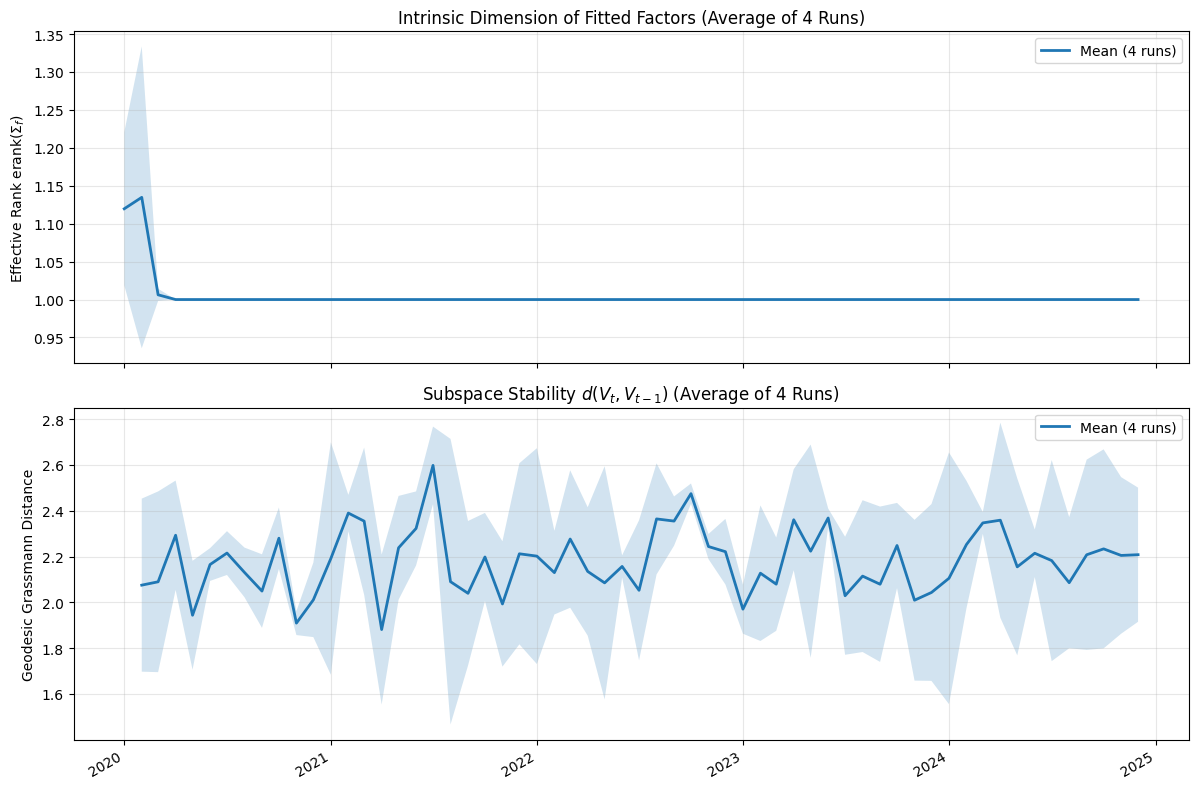

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# choose 4 seeds (edit as needed)
selected_seeds = sorted(results)[:4]

# stack + average
diag_stack = []
for s in selected_seeds:
    d = results[s]["diag"].copy()
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d["erank"] = pd.to_numeric(d["erank"], errors="coerce")
    d["grassmann_dist"] = pd.to_numeric(d["grassmann_dist"], errors="coerce")
    d = d.dropna(subset=["yyyymm"])
    d["seed"] = s
    diag_stack.append(d[["yyyymm", "erank", "grassmann_dist", "seed"]])

diag_all = pd.concat(diag_stack, ignore_index=True)

diag_avg = (
    diag_all.groupby("yyyymm", as_index=False)
    .agg(
        erank_mean=("erank", "mean"),
        gdist_mean=("grassmann_dist", "mean"),
        erank_std=("erank", "std"),
        gdist_std=("grassmann_dist", "std"),
    )
    .sort_values("yyyymm")
)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# mean line
axes[0].plot(diag_avg["yyyymm"], diag_avg["erank_mean"], linewidth=2, label="Mean (4 runs)")
axes[1].plot(diag_avg["yyyymm"], diag_avg["gdist_mean"], linewidth=2, label="Mean (4 runs)")

# optional uncertainty band (±1 std)
axes[0].fill_between(
    diag_avg["yyyymm"],
    diag_avg["erank_mean"] - diag_avg["erank_std"].fillna(0),
    diag_avg["erank_mean"] + diag_avg["erank_std"].fillna(0),
    alpha=0.2,
)
axes[1].fill_between(
    diag_avg["yyyymm"],
    diag_avg["gdist_mean"] - diag_avg["gdist_std"].fillna(0),
    diag_avg["gdist_mean"] + diag_avg["gdist_std"].fillna(0),
    alpha=0.2,
)

axes[0].set_ylabel(r"Effective Rank $\mathrm{erank}(\Sigma_f)$")
axes[0].set_title("Intrinsic Dimension of Fitted Factors (Average of 4 Runs)")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].set_ylabel("Geodesic Grassmann Distance")
axes[1].set_title(r"Subspace Stability $d(V_t, V_{t-1})$ (Average of 4 Runs)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(1))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()



In [53]:

selected_seeds = sorted(results)[:4]  # pick the 4 runs you want

pred_stack = []
for s in selected_seeds:
    d = results[s]["pred"].copy()  # if tuple-style, use: results[s][0]
    d["permno"] = pd.to_numeric(d["permno"], errors="coerce")
    d["yyyymm"] = pd.to_datetime(d["yyyymm"], errors="coerce")
    d["y_pred"] = pd.to_numeric(d["y_pred"], errors="coerce")
    d["y_true"] = pd.to_numeric(d["y_true"], errors="coerce")
    d["seed"] = s
    pred_stack.append(d[["permno", "yyyymm", "y_pred", "y_true", "seed"]])

pred_all = pd.concat(pred_stack, ignore_index=True).dropna(subset=["permno", "yyyymm", "y_pred"])

pred_avg_df = (
    pred_all
    .groupby(["permno", "yyyymm"], as_index=False)
    .agg(
        y_pred_avg=("y_pred", "mean"),
        y_pred_std=("y_pred", "std"),
        y_true=("y_true", "first"),
        n_runs=("seed", "nunique"),
    )
    .sort_values(["yyyymm", "permno"])
    .reset_index(drop=True)
)

pred_avg_df.head()

,permno,yyyymm,y_pred_avg,y_pred_std,y_true,n_runs
0,10104,2020-01-01,-0.005788,0.022979,-0.057007,4
1,10107,2020-01-01,0.032250,0.037439,-0.045292,4
2,11308,2020-01-01,0.002864,0.006262,-0.084075,4
3,11850,2020-01-01,0.000182,0.026925,-0.157920,4
4,12060,2020-01-01,-0.022519,0.101911,-0.126104,4


Annualized Return : 21.27%
Annualized Vol    : 18.15%
Sharpe Ratio      : 1.17
Max Drawdown      : -17.27%
Hit Rate          : 65.00%


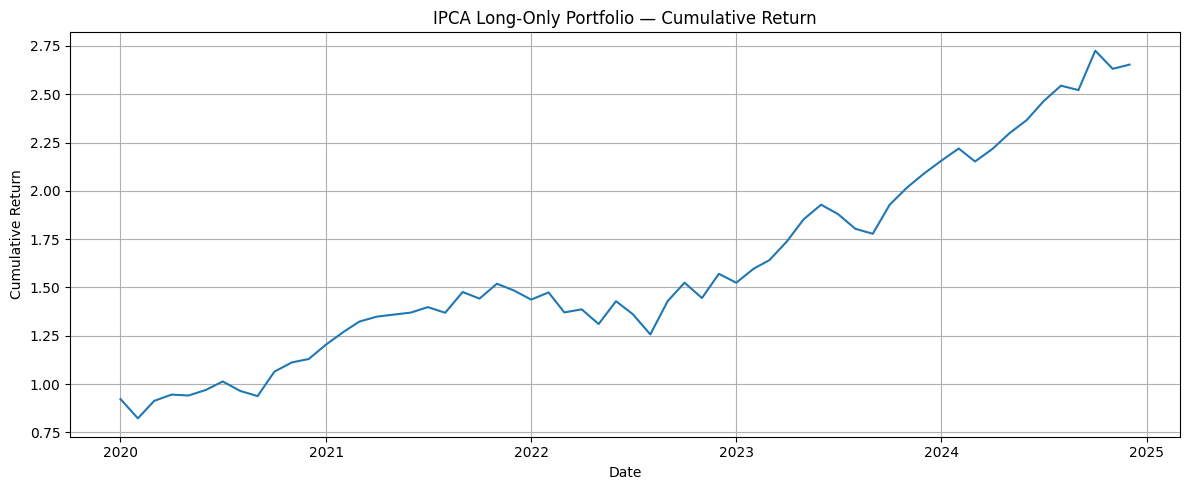

{'ann_ret': 0.21274918463144296,
 'ann_vol': 0.1814621366443244,
 'sharpe': 1.1724163980745077,
 'max_dd': -0.17267285624693046,
 'hit_rate': 0.65}

In [54]:
from src.portfolio_utils import (
    build_long_only_portfolio,
    compute_portfolio_returns,
    portfolio_performance,
    plot_cumulative,
)

# map averaged predictions to portfolio utils expected names
port_input = pred_avg_df.rename(columns={"y_pred_avg": "y_pred"})[
    ["permno", "yyyymm", "y_pred", "y_true"]
].copy()

# build portfolio (example: top 100 each month, long-only)
port = build_long_only_portfolio(
    pred_df=port_input,
    top_n=100,      # change as needed
    threshold=0.0,  # keep only positive expected return
)

monthly = compute_portfolio_returns(port)
stats = portfolio_performance(monthly)
plot_cumulative(monthly)

stats

Annualized Return : 20.18%
Annualized Vol    : 18.54%
Sharpe Ratio      : 1.09
Max Drawdown      : -19.03%
Hit Rate          : 66.67%


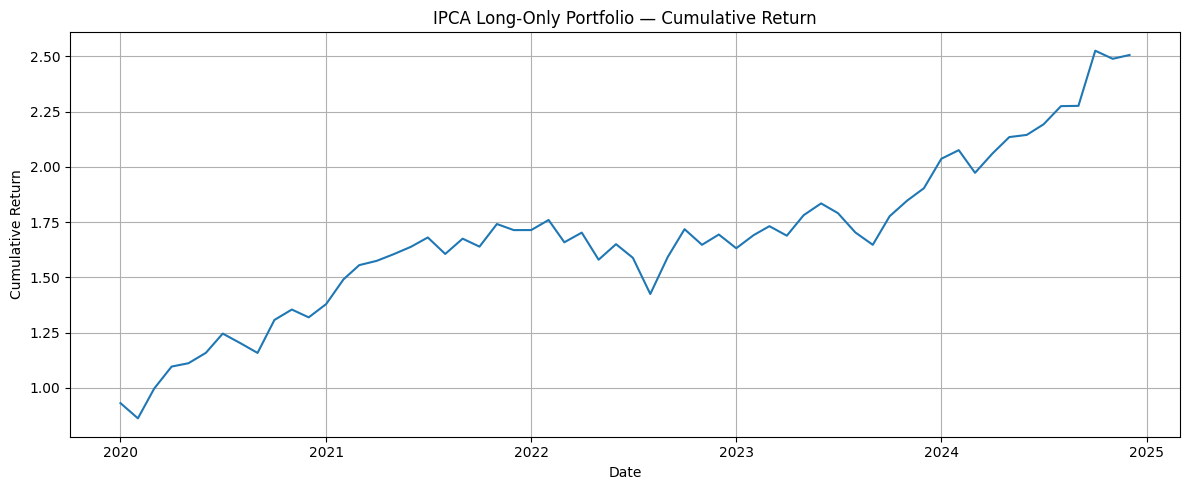

{'ann_ret': 0.2017576098629593,
 'ann_vol': 0.18536870176694323,
 'sharpe': 1.0884124878676724,
 'max_dd': -0.19029010340864436,
 'hit_rate': 0.6666666666666666}

In [55]:
port = build_long_only_portfolio(
    pred_df=pred_df_in,
    top_n=50,      # change as needed
    threshold=0.0001,  # keep only positive expected return
)

monthly = compute_portfolio_returns(port)
stats = portfolio_performance(monthly)
plot_cumulative(monthly)

stats

In [52]:
diag_stack

[       yyyymm     erank  grassmann_dist  seed
 0  2020-01-01  1.172935             NaN     0
 1  2020-02-01  1.423668        1.567884     0
 2  2020-03-01  1.017022        1.781453     0
 3  2020-04-01  1.000000        2.530816     0
 4  2020-05-01  1.000000        2.022188     0
 5  2020-06-01  1.000000        2.058250     0
 6  2020-07-01  1.000000        2.234832     0
 7  2020-08-01  1.000000        2.225229     0
 8  2020-09-01  1.000000        1.998823     0
 9  2020-10-01  1.000000        2.103373     0
 10 2020-11-01  1.000000        1.892558     0
 11 2020-12-01  1.000000        2.242695     0
 12 2021-01-01  1.000000        2.455994     0
 13 2021-02-01  1.000000        2.289391     0
 14 2021-03-01  1.000000        2.506023     0
 15 2021-04-01  1.000000        1.633968     0
 16 2021-05-01  1.000000        1.944103     0
 17 2021-06-01  1.000000        2.403222     0
 18 2021-07-01  1.000000        2.645900     0
 19 2021-08-01  1.000000        1.508574     0
 20 2021-09-0